In [2]:
# ============================================
# CELL 0 — SETUP / CONFIG / IMPORTS
# ============================================

# --- FILE PATHS (edit to your dataset locations) ---
TRANSACTIONS_PATH = "transactions_train.csv"   # or .parquet
ARTICLES_PATH     = "articles.csv"       # optional for category features

# --- CONFIGURATION ---
ID_CUSTOMER = "customer_id"
ID_ITEM     = "article_id"
DT_COL      = "t_dat"
PRICE_COL   = "price"
CAT_COL     = "garment_group_name"   # set None if not used
RANDOM_STATE = 42

# Feature list placeholders (will be filled after feature engineering)
numerical_features   = []
categorical_features = []
binary_features      = []
features             = []

# ============================================
# IMPORTS
# ============================================
import os, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Machine-learning tools
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, average_precision_score

# Neural-network (TensorFlow / Keras)
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Utility
from sklearn.utils import check_random_state
import joblib
from datetime import datetime

# Display settings
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

# Fix random seeds for reproducibility
np.random.seed(RANDOM_STATE)
tf.keras.utils.set_random_seed(RANDOM_STATE)

# ============================================
# LOAD DATA
# ============================================
# Transactions
if TRANSACTIONS_PATH.endswith(".csv"):
    transactions = pd.read_csv(TRANSACTIONS_PATH)
elif TRANSACTIONS_PATH.endswith(".parquet"):
    transactions = pd.read_parquet(TRANSACTIONS_PATH)
else:
    raise ValueError("Unsupported format for TRANSACTIONS_PATH")

# Articles (optional)
if CAT_COL is not None:
    try:
        if ARTICLES_PATH.endswith(".csv"):
            articles = pd.read_csv(ARTICLES_PATH)
        elif ARTICLES_PATH.endswith(".parquet"):
            articles = pd.read_parquet(ARTICLES_PATH)
        else:
            raise ValueError("Unsupported format for ARTICLES_PATH")
    except FileNotFoundError:
        print("No articles file found — skipping category features.")
        articles = pd.DataFrame()
        CAT_COL = None
else:
    articles = pd.DataFrame()

# ============================================
# BASIC VALIDATION
# ============================================
# Required columns
required_cols = [ID_CUSTOMER, ID_ITEM, DT_COL, PRICE_COL]
missing = [c for c in required_cols if c not in transactions.columns]
if missing:
    raise ValueError(f"Missing required columns in `transactions`: {missing}")

# Datetime conversion
transactions[DT_COL] = pd.to_datetime(transactions[DT_COL], errors="coerce")
if transactions[DT_COL].isna().any():
    raise ValueError(f"Some {DT_COL} values could not be parsed to datetime.")

# Category column presence
if CAT_COL and not articles.empty and CAT_COL not in articles.columns:
    raise ValueError(f"Column `{CAT_COL}` not found in `articles` dataset.")

# Summary
print("Data loaded and validated")
print(f"Transactions: {len(transactions):,} rows, columns: {transactions.columns.tolist()}")
if not articles.empty:
    print(f"Articles: {len(articles):,} rows; category col: {CAT_COL}")
print(f"Random seed: {RANDOM_STATE}")
print("Ready to build features and create X_train / X_val splits in next cells.")


✅ Data loaded and validated
Transactions: 31,788,324 rows, columns: ['t_dat', 'customer_id', 'article_id', 'price', 'sales_channel_id']
Articles: 105,542 rows; category col: garment_group_name
Random seed: 42
Ready to build features and create X_train / X_val splits in next cells.


In [3]:

# CELL 1 — BUILD FEATURES + TRAIN/VAL SPLIT (outputs X_train, X_val, y_train, y_val)

import numpy as np
import pandas as pd
from sklearn.model_selection import GroupShuffleSplit
from sklearn.utils import check_random_state

# ---------- 1) Time split: past (hist) vs target window (no future peeking) ----------
max_date = transactions[DT_COL].max()
cutoff_date = max_date - pd.Timedelta(days=7)  # 7-day validation target window
hist   = transactions[transactions[DT_COL] <  cutoff_date].copy()   # ONLY for feature engineering
target = transactions[transactions[DT_COL] >= cutoff_date].copy()   # labels/candidates

print(f"Max date: {max_date.date()} | Cutoff (start of target window): {cutoff_date.date()}")
print(f"hist rows: {len(hist):,} | target rows: {len(target):,}")

# ---------- 2) Past-only aggregates from hist ----------
# User average price
user_avg_price = (
    hist.groupby(ID_CUSTOMER, as_index=False)[PRICE_COL]
        .mean()
        .rename(columns={PRICE_COL: "user_avg_price"})
        .astype({"user_avg_price": "float32"})
)

# Item average price
item_avg_price = (
    hist.groupby(ID_ITEM, as_index=False)[PRICE_COL]
        .mean()
        .rename(columns={PRICE_COL: "item_avg_price"})
        .astype({"item_avg_price": "float32"})
)

# User recency (days since last purchase) relative to cutoff_date
user_last_purchase = (
    hist.groupby(ID_CUSTOMER, as_index=False)[DT_COL]
        .max()
        .rename(columns={DT_COL: "last_purchase_date"})
)
user_last_purchase["recency_days"] = (cutoff_date - user_last_purchase["last_purchase_date"]).dt.days
user_last_purchase["recency_days"] = (
    user_last_purchase["recency_days"]
    .fillna(user_last_purchase["recency_days"].max() + 1)
    .astype("int32")
)

# category history (has bought this category before — from hist only)
if CAT_COL is not None and not articles.empty:
    hist_cat = hist[[ID_CUSTOMER, ID_ITEM]].merge(
        articles[[ID_ITEM, CAT_COL]], on=ID_ITEM, how="left"
    )
    user_category_history = (
        hist_cat[[ID_CUSTOMER, CAT_COL]].dropna().drop_duplicates()
    )
else:
    user_category_history = None

# ---------- 3) Build labels in target and simple negative sampling ----------
# Positives: customer-item pairs bought in target window
positives = target[[ID_CUSTOMER, ID_ITEM]].drop_duplicates()
positives = positives.assign(label=1)

# Negatives: for each customer in target, sample items they didn't buy in target
rng = check_random_state(RANDOM_STATE)
unique_customers = positives[ID_CUSTOMER].unique()
all_items = transactions[ID_ITEM].unique()

pos_map = positives.groupby(ID_CUSTOMER)[ID_ITEM].apply(set).to_dict()

negatives_per_pos = 1  # tweak as needed
neg_rows = []
for cust in unique_customers:
    pos_items = pos_map.get(cust, set())
    n_pos = len(pos_items)
    n_neg = n_pos * negatives_per_pos
    if n_neg <= 0:
        continue
    pool = np.setdiff1d(all_items, np.fromiter(pos_items, dtype=all_items.dtype))
    if len(pool) == 0:
        continue
    sampled = rng.choice(pool, size=min(n_neg, len(pool)), replace=False)
    neg_rows.extend([(cust, it, 0) for it in sampled])

negatives = pd.DataFrame(neg_rows, columns=[ID_CUSTOMER, ID_ITEM, "label"])
training_pairs = pd.concat([positives, negatives], ignore_index=True)

print(f"Positives: {len(positives):,} | Negatives: {len(negatives):,} | Total pairs: {len(training_pairs):,}")

# ---------- 4) Join engineered features to candidate pairs ----------
training_data = (
    training_pairs
    .merge(user_avg_price, on=ID_CUSTOMER, how="left")
    .merge(item_avg_price, on=ID_ITEM,      how="left")
    .merge(user_last_purchase[[ID_CUSTOMER, "recency_days"]], on=ID_CUSTOMER, how="left")
)

# attach item category and "has_bought_category_before"
if CAT_COL is not None and not articles.empty:
    training_data = training_data.merge(articles[[ID_ITEM, CAT_COL]], on=ID_ITEM, how="left")
    if user_category_history is not None:
        training_data["has_bought_category_before"] = (
            training_data[[ID_CUSTOMER, CAT_COL]]
            .merge(
                user_category_history.assign(has_bought_category_before=1),
                on=[ID_CUSTOMER, CAT_COL], how="left"
            )["has_bought_category_before"]
            .fillna(0).astype("int8")
        )
    else:
        training_data["has_bought_category_before"] = 0

# Fill missing engineered numeric features
for col in ["user_avg_price", "item_avg_price", "recency_days"]:
    if col in training_data.columns:
        training_data[col] = training_data[col].fillna(training_data[col].median())

# ---------- 5) Define feature lists (explicit and leakage-safe) ----------
# IDs must never be features
id_like = {ID_CUSTOMER, ID_ITEM}

# Base numeric engineered features
numerical_features = [c for c in ["user_avg_price", "item_avg_price", "recency_days"]
                      if c in training_data.columns]

# Optional categorical feature
categorical_features = []
if CAT_COL is not None and CAT_COL in training_data.columns:
    categorical_features.append(CAT_COL)

# Optional binary features (if you defined any earlier in Cell 0)
binary_features = [c for c in (binary_features if 'binary_features' in globals() else [])
                   if c in training_data.columns and c not in id_like]

# Final ordered features
features = [*numerical_features, *categorical_features, *binary_features]

print("Numerical features:", numerical_features)
print("Categorical features:", categorical_features)
print("Binary features:", binary_features)
print("Total features:", len(features))

# ---------- 6) Group-aware split by customer (prevents customer overlap) ----------
y = training_data["label"].astype(int).values
groups = training_data[ID_CUSTOMER].values

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)
train_idx, val_idx = next(gss.split(training_data, y, groups=groups))

train_df = training_data.iloc[train_idx].reset_index(drop=True)
val_df   = training_data.iloc[val_idx].reset_index(drop=True)

X_train = train_df[features].copy()
X_val   = val_df[features].copy()
y_train = train_df["label"].values
y_val   = val_df["label"].values

print(f"Train pairs: {len(train_df):,} | Val pairs: {len(val_df):,}")
print("X_train shape:", X_train.shape, "| X_val shape:", X_val.shape)


Max date: 2020-09-22 | Cutoff (start of target window): 2020-09-15
hist rows: 31,521,960 | target rows: 266,364
Positives: 236,622 | Negatives: 236,622 | Total pairs: 473,244
Numerical features: ['user_avg_price', 'item_avg_price', 'recency_days']
Categorical features: ['garment_group_name']
Binary features: []
Total features: 4
Train pairs: 378,554 | Val pairs: 94,690
X_train shape: (378554, 4) | X_val shape: (94690, 4)


In [4]:
# ============================================
# CELL NN-1 — PREPROCESS FOR FFNN (FIT ON TRAIN ONLY)
# ============================================
import os
import numpy as np
from sklearn import __version__ as skver
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import joblib

# Ensure output folder exists
os.makedirs("models", exist_ok=True)

# Make sure feature lists align with the actual columns we have
id_like = {ID_CUSTOMER, ID_ITEM}
numerical_features   = [c for c in numerical_features   if c in X_train.columns and c not in id_like]
categorical_features = [c for c in categorical_features if c in X_train.columns and c not in id_like]
binary_features      = [c for c in binary_features      if c in X_train.columns and c not in id_like]
features             = [c for c in features if c in X_train.columns and c not in id_like]

# Version-safe dense OneHotEncoder for NN input
def make_ohe_dense():
    major_minor = tuple(int(x) for x in skver.split(".")[:2])
    if major_minor >= (1, 2):
        # sklearn >= 1.2: use sparse_output
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    else:
        # sklearn < 1.2: use sparse
        return OneHotEncoder(handle_unknown="ignore", sparse=False)

num_pipe = Pipeline([("scaler", StandardScaler())])
cat_pipe = Pipeline([("ohe", make_ohe_dense())]) if len(categorical_features) else "drop"

# Build ColumnTransformer: numeric -> scaled, categorical -> dense OHE, binary -> passthrough
preprocessor_nn = ColumnTransformer(
    transformers=[
        ("num", num_pipe, numerical_features),
        ("cat", cat_pipe, categorical_features),
        ("bin", "passthrough", binary_features),
    ],
    remainder="drop"
)

# Fit on TRAIN only; transform both
X_train_np = preprocessor_nn.fit_transform(X_train[features])
X_val_np   = preprocessor_nn.transform(X_val[features])

input_dim = X_train_np.shape[1]
print(f"Preprocessed shapes — Train: {X_train_np.shape}, Val: {X_val_np.shape} | input_dim={input_dim}")

# Save the preprocessor for inference later
prep_path = "models/preprocessor_nn.joblib"
joblib.dump(preprocessor_nn, prep_path)
print(f"Saved preprocessor to: {prep_path}")


Preprocessed shapes — Train: (378554, 24), Val: (94690, 24) | input_dim=24
✅ Saved preprocessor to: models/preprocessor_nn.joblib


In [5]:
# ============================================
# CELL 3 — BUILD & TRAIN FFNN (EARLY STOPPING)
# ============================================
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.utils.class_weight import compute_class_weight

# Reproducibility
tf.keras.utils.set_random_seed(RANDOM_STATE)

# Optional: class weights (helps if classes are imbalanced)
classes = np.array([0, 1])
class_weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_train)
class_weight_dict = {int(c): float(w) for c, w in zip(classes, class_weights)}
print("Class weights:", class_weight_dict)

def build_ffnn(input_dim: int) -> keras.Model:
    inputs = keras.Input(shape=(input_dim,), name="features")
    x = layers.Dense(256, activation="relu", kernel_initializer="he_normal")(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.30)(x)

    x = layers.Dense(128, activation="relu", kernel_initializer="he_normal")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.30)(x)

    x = layers.Dense(64, activation="relu", kernel_initializer="he_normal")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.20)(x)

    outputs = layers.Dense(1, activation="sigmoid", name="prob")(x)
    model = keras.Model(inputs, outputs, name="ffnn_binary")
    return model

model = build_ffnn(input_dim)
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=[
        keras.metrics.AUC(name="auc"),
        keras.metrics.Precision(name="precision"),
        keras.metrics.Recall(name="recall"),
    ],
)
model.summary()

callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_auc", mode="max", patience=10, restore_best_weights=True, verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_auc", mode="max", factor=0.5, patience=5, min_lr=1e-6, verbose=1
    ),
]

BATCH_SIZE = 4096
EPOCHS = 200

history = model.fit(
    X_train_np, y_train,
    validation_data=(X_val_np, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=class_weight_dict,
    callbacks=callbacks,
    verbose=1,
)


Class weights: {0: 1.0, 1: 1.0}


Model: "ffnn_binary"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ features (InputLayer)           │ (None, 24)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │         6,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ prob (Dense)                    │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 49,409 (193.00 KB)

 Trainable params: 48,513 (189.50 KB)

 Non-trainable params: 896 (3.50 KB)

Epoch 1/200
93/93 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - auc: 0.6643 - loss: 0.6792 - precision: 0.6158 - recall: 0.6515 - val_auc: 0.7196 - val_loss: 0.6274 - val_precision: 0.6345 - val_recall: 0.7806 - learning_rate: 0.0010
Epoch 2/200
93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - auc: 0.7056 - loss: 0.6287 - precision: 0.6398 - recall: 0.7066 - val_auc: 0.7334 - val_loss: 0.6115 - val_precision: 0.6284 - val_recall: 0.8160 - learning_rate: 0.0010
Epoch 3/200
93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - auc: 0.7175 - loss: 0.6161 - precision: 0.6455 - recall: 0.7255 - val_auc: 0.7378 - val_loss: 0.6022 - val_precision: 0.6371 - val_recall: 0.7995 - learning_rate: 0.0010
Epoch 4/200
93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - auc: 0.7245 - loss: 0.6091 - precision: 0.6489 - recall: 0.7348 - val_auc: 0.7398 - val_loss: 0.5970 - val_precision: 0.6423 - val_recall: 0.7896 - learning_rate: 0.0010
Epoch 5/200
93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - auc: 0.7289 - loss: 0.6043 - precision: 0.6520 - r

=== FFNN Summary ===
Train ROC AUC: 0.8495 | PR AUC: 0.8426
Val   ROC AUC: 0.8469 | PR AUC: 0.8406
Chosen threshold (Youden's J on val): 0.5204

--- Confusion Matrices ---
[Train] TP:143030 FP:38427 TN:150850 FN:46247 | Precision:0.7882 Recall:0.7557
              precision    recall  f1-score   support

           0     0.7654    0.7970    0.7808    189277
           1     0.7882    0.7557    0.7716    189277

    accuracy                         0.7763    378554
   macro avg     0.7768    0.7763    0.7762    378554
weighted avg     0.7768    0.7763    0.7762    378554

[Validation] TP:35742 FP:9822 TN:37523 FN:11603 | Precision:0.7844 Recall:0.7549
              precision    recall  f1-score   support

           0     0.7638    0.7925    0.7779     47345
           1     0.7844    0.7549    0.7694     47345

    accuracy                         0.7737     94690
   macro avg     0.7741    0.7737    0.7737     94690
weighted avg     0.7741    0.7737    0.7737     94690



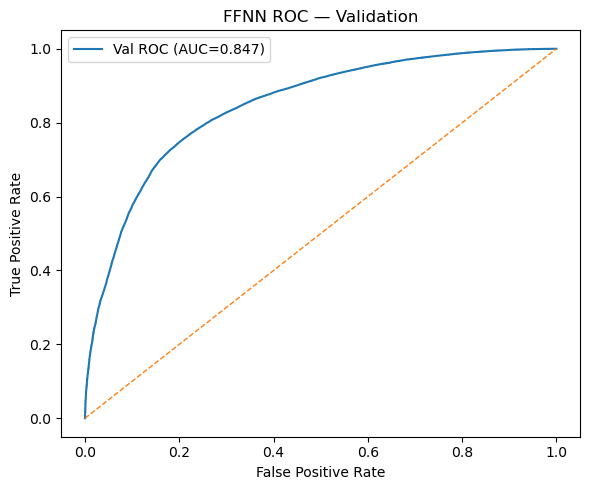

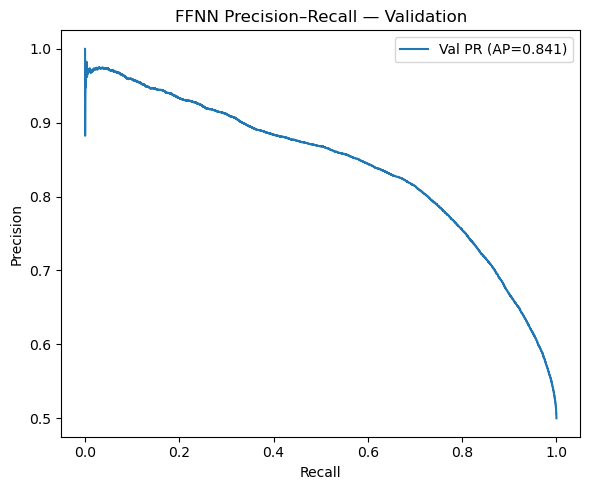

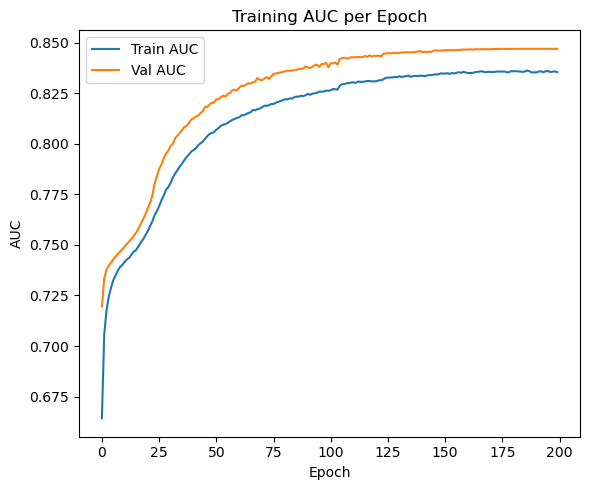

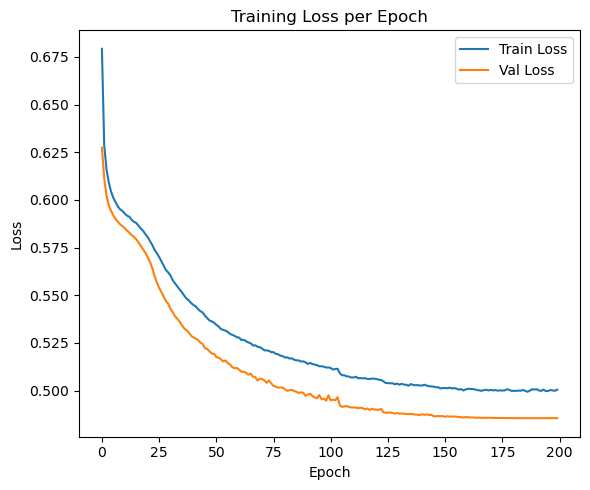

In [6]:
# ============================================
# CELL 4 — EVALUATION & CURVES
# ============================================
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    roc_curve, precision_recall_curve,
    confusion_matrix, classification_report,
)

# Probabilities
train_prob = model.predict(X_train_np, verbose=0).ravel()
val_prob   = model.predict(X_val_np,   verbose=0).ravel()

# AUC / PR-AUC
train_auc = roc_auc_score(y_train, train_prob)
val_auc   = roc_auc_score(y_val,   val_prob)
train_ap  = average_precision_score(y_train, train_prob)
val_ap    = average_precision_score(y_val,   val_prob)

print("=== FFNN Summary ===")
print(f"Train ROC AUC: {train_auc:.4f} | PR AUC: {train_ap:.4f}")
print(f"Val   ROC AUC: {val_auc:.4f} | PR AUC: {val_ap:.4f}")

# Threshold by Youden's J
fpr_v, tpr_v, thr_v = roc_curve(y_val, val_prob)
youden_idx = np.argmax(tpr_v - fpr_v)
best_thr = thr_v[youden_idx]
print(f"Chosen threshold (Youden's J on val): {best_thr:.4f}")

def cm_report(name, y_true, y_prob, thr):
    y_pred = (y_prob >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    prec = tp / (tp + fp) if (tp + fp) else 0.0
    rec  = tp / (tp + fn) if (tp + fn) else 0.0
    print(f"[{name}] TP:{tp} FP:{fp} TN:{tn} FN:{fn} | Precision:{prec:.4f} Recall:{rec:.4f}")
    print(classification_report(y_true, y_pred, digits=4))

print("\n--- Confusion Matrices ---")
cm_report("Train", y_train, train_prob, best_thr)
cm_report("Validation", y_val, val_prob, best_thr)

# ROC Curve (Validation)
prec_v, rec_v, _ = precision_recall_curve(y_val, val_prob)

plt.figure(figsize=(6,5))
plt.plot(fpr_v, tpr_v, label=f"Val ROC (AUC={val_auc:.3f})")
plt.plot([0,1],[0,1],'--', linewidth=1)
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("FFNN ROC — Validation"); plt.legend(); plt.tight_layout(); plt.show()

# PR Curve (Validation)
plt.figure(figsize=(6,5))
plt.plot(rec_v, prec_v, label=f"Val PR (AP={val_ap:.3f})")
plt.xlabel("Recall"); plt.ylabel("Precision")
plt.title("FFNN Precision–Recall — Validation"); plt.legend(); plt.tight_layout(); plt.show()

# Training curves
plt.figure(figsize=(6,5))
plt.plot(history.history["auc"], label="Train AUC")
plt.plot(history.history["val_auc"], label="Val AUC")
plt.xlabel("Epoch"); plt.ylabel("AUC"); plt.title("Training AUC per Epoch"); plt.legend()
plt.tight_layout(); plt.show()

plt.figure(figsize=(6,5))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.title("Training Loss per Epoch"); plt.legend()
plt.tight_layout(); plt.show()


In [7]:
# ============================================
# CELL 5 — SAVE MODEL, PREPROCESSOR, METADATA
# ============================================
import os, json, shutil
from datetime import datetime
import joblib

# Paths
os.makedirs("models", exist_ok=True)
ts = datetime.now().strftime("%Y%m%d_%H%M%S")
model_dir = f"models/ffnn_{ts}"
os.makedirs(model_dir, exist_ok=True)

# Save Keras model (TF's native .keras format)
model_path = os.path.join(model_dir, "model.keras")
model.save(model_path)
print(f"✅ Saved FFNN to: {model_path}")

# Ensure the preprocessor from Cell 2 is saved alongside
try:
    # If the in-memory object exists, dump it here
    joblib.dump(preprocessor_nn, os.path.join(model_dir, "preprocessor_nn.joblib"))
    print("✅ Saved preprocessor to:", os.path.join(model_dir, "preprocessor_nn.joblib"))
except NameError:
    # Fallback: copy from default save location (Cell 2)
    src = "models/preprocessor_nn.joblib"
    dst = os.path.join(model_dir, "preprocessor_nn.joblib")
    if os.path.exists(src):
        shutil.copy2(src, dst)
        print("✅ Copied preprocessor from:", src)
    else:
        print("⚠️ Preprocessor object/file not found. Re-run Cell 2 to save it.")

# Save metadata (use what’s available in the session)
meta = {
    "cutoff_date": str(cutoff_date) if "cutoff_date" in globals() else None,
    "features": features if "features" in globals() else None,
    "numerical_features": numerical_features if "numerical_features" in globals() else None,
    "categorical_features": categorical_features if "categorical_features" in globals() else None,
    "binary_features": binary_features if "binary_features" in globals() else None,
    "batch_size": BATCH_SIZE if "BATCH_SIZE" in globals() else None,
    "best_val_auc": float(max(history.history.get("val_auc", [0.0]))),
    "train_auc": float(roc_auc_score(y_train, model.predict(X_train_np, verbose=0).ravel())),
    "val_auc": float(roc_auc_score(y_val,   model.predict(X_val_np,   verbose=0).ravel())),
}
with open(os.path.join(model_dir, "meta.json"), "w") as f:
    json.dump(meta, f, indent=2)
print(f"🧠 Saved metadata to: {os.path.join(model_dir, 'meta.json')}")


✅ Saved FFNN to: models/ffnn_20251016_154913/model.keras
✅ Saved preprocessor to: models/ffnn_20251016_154913/preprocessor_nn.joblib
🧠 Saved metadata to: models/ffnn_20251016_154913/meta.json
